# PubMedQA Medical Question Answering - Final Colab Notebook

This notebook is **Colab-ready** and reads the dataset from a local **`data/` folder**.

## Expected files inside `data/`
- `ori_pqal.json`
- `test_ground_truth.json`

## Models included
1. TF-IDF + Logistic Regression  
2. TF-IDF + N-grams + Logistic Regression  
3. Sentence-BERT embeddings + Logistic Regression  
4. BioBERT fine-tuning for sequence classification  

## Notes
- `TF-IDF` and `Sentence-BERT` are usually faster.
- `BioBERT` needs a **GPU** in Colab for practical training time.
- This notebook uses:
  - **train/validation** from the part of `ori_pqal.json` **not listed** in `test_ground_truth.json`
  - **test set** from IDs present in `test_ground_truth.json`


In [1]:
# If running in Colab, install required packages
# You can run this once, then Runtime -> Restart session if needed.

!pip -q install transformers datasets sentence-transformers scikit-learn seaborn accelerate


In [2]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

from sklearn.utils.class_weight import compute_class_weight
import inspect


In [3]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Data loading

The notebook first tries these locations:

1. `/content/data`
2. `./data`
3. `/mnt/data` (useful if you test locally in this environment)

In Colab, upload your files so they end up in `/content/data/`.


In [4]:
# -----------------------------
# Find data folder
# -----------------------------
candidate_dirs = [
    Path("/content/data"),
    Path("./data"),
    Path("/mnt/data"),
]

data_dir = None
for d in candidate_dirs:
    if (d / "ori_pqal.json").exists() and (d / "test_ground_truth.json").exists():
        data_dir = d
        break

if data_dir is None:
    raise FileNotFoundError(
        "Could not find 'ori_pqal.json' and 'test_ground_truth.json'. "
        "Please place both files inside a folder named 'data'."
    )

print("Using data directory:", data_dir.resolve())


Using data directory: /content/data


In [5]:
# -----------------------------
# Load JSON files
# -----------------------------
with open(data_dir / "ori_pqal.json", "r", encoding="utf-8") as f:
    full_data = json.load(f)

with open(data_dir / "test_ground_truth.json", "r", encoding="utf-8") as f:
    test_ground_truth = json.load(f)

print("Total examples in ori_pqal.json:", len(full_data))
print("Total test IDs in test_ground_truth.json:", len(test_ground_truth))
print("Overlap:", len(set(full_data.keys()) & set(test_ground_truth.keys())))


Total examples in ori_pqal.json: 1000
Total test IDs in test_ground_truth.json: 500
Overlap: 500


In [6]:
# -----------------------------
# Label mapping + normalization
# -----------------------------
label2id = {"yes": 0, "no": 1, "maybe": 2}
id2label = {0: "yes", 1: "no", 2: "maybe"}

def normalize_label(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = x.replace("\n", " ").replace("\t", " ")
    x = " ".join(x.split())
    return x if x in label2id else None

# -----------------------------
# Build dataframe
# -----------------------------
records = []
for pmid, item in full_data.items():
    question = str(item.get("QUESTION", "")).strip()

    contexts = item.get("CONTEXTS", [])
    if isinstance(contexts, list):
        context = " ".join([str(c).strip() for c in contexts if str(c).strip()])
    else:
        context = str(contexts).strip()

    label_text = normalize_label(item.get("final_decision", None))

    records.append({
        "pmid": str(pmid),
        "question": question,
        "context": context,
        "text": f"Question: {question} Context: {context}",
        "label_text": label_text,
        "year": item.get("YEAR", None),
        "reasoning_required_pred": item.get("reasoning_required_pred", None),
        "reasoning_free_pred": item.get("reasoning_free_pred", None),
    })

df = pd.DataFrame(records)

# Keep only valid labels
df = df[df["label_text"].isin(["yes", "no", "maybe"])].copy()
df["label"] = df["label_text"].map(label2id)

print("Full dataframe shape:", df.shape)
print("\nFull dataframe label distribution:")
print(df["label_text"].value_counts())
print("\nEncoded label distribution:")
print(df["label"].value_counts().sort_index())


Full dataframe shape: (1000, 9)

Full dataframe label distribution:
label_text
yes      552
no       338
maybe    110
Name: count, dtype: int64

Encoded label distribution:
label
0    552
1    338
2    110
Name: count, dtype: int64


In [7]:
# -----------------------------
# Create train/val/test split using provided test IDs
# -----------------------------
test_ids = set(map(str, test_ground_truth.keys()))

test_df = df[df["pmid"].isin(test_ids)].copy()
trainval_df = df[~df["pmid"].isin(test_ids)].copy()

# Use ground-truth file as final source of truth for test labels
test_df["label_text_from_gt"] = test_df["pmid"].map(test_ground_truth)
test_df["label_text_from_gt"] = test_df["label_text_from_gt"].apply(normalize_label)

# Check whether anything is unmapped in GT
bad_gt = test_df[test_df["label_text_from_gt"].isna()]
if len(bad_gt) > 0:
    print("\nWARNING: Some test labels from ground truth are invalid:")
    display(bad_gt[["pmid", "label_text_from_gt"]].head())

mismatch_count = (test_df["label_text"] != test_df["label_text_from_gt"]).sum()

print("Train+Val size:", len(trainval_df))
print("Test size:", len(test_df))
print("Label mismatches between ori_pqal and test_ground_truth:", mismatch_count)

# Use GT file as final source of truth for test labels
test_df["label_text"] = test_df["label_text_from_gt"]
test_df["label"] = test_df["label_text"].map(label2id)
test_df.drop(columns=["label_text_from_gt"], inplace=True)

# Safety check
assert test_df["label"].isna().sum() == 0, "Some test labels could not be mapped."


# -----------------------------
# Exact debug checks for "maybe"
# -----------------------------
print("\nUnique raw values in test_ground_truth after normalization:")
print(sorted(set(normalize_label(v) for v in test_ground_truth.values())))

print("\nTest label_text counts after GT mapping:")
print(test_df["label_text"].value_counts(dropna=False))

print("\nTest numeric label counts after GT mapping:")
print(test_df["label"].value_counts(dropna=False).sort_index())

maybe_rows = test_df.loc[test_df["label_text"] == "maybe", ["pmid", "label_text", "label"]].copy()
print(f"\nNumber of test rows where label_text == 'maybe': {len(maybe_rows)}")
if len(maybe_rows) > 0:
    display(maybe_rows.head(20))

bad_maybe_rows = test_df.loc[(test_df["label_text"] == "maybe") & (test_df["label"] != 2), ["pmid", "label_text", "label"]].copy()
print(f"\nRows where label_text == 'maybe' but numeric label != 2: {len(bad_maybe_rows)}")
if len(bad_maybe_rows) > 0:
    display(bad_maybe_rows)
else:
    print("All 'maybe' rows are correctly mapped to label 2.")

pred_debug_note = '''
Reminder:
- true label 0 = yes
- true label 1 = no
- true label 2 = maybe

If BioBERT predicts many 0s later, that means the model is predicting "yes" a lot.
It does NOT mean the true "maybe" labels were mapped to 0.
'''
print("\n" + pred_debug_note)


train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,
    random_state=SEED,
    stratify=trainval_df["label"]
)

print("\nFinal split sizes:")
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} label_text distribution:")
    print(split_df["label_text"].value_counts())
    print(f"\n{name} encoded label distribution:")
    print(split_df["label"].value_counts().sort_index())


Train+Val size: 500
Test size: 500
Label mismatches between ori_pqal and test_ground_truth: 0

Unique raw values in test_ground_truth after normalization:
['maybe', 'no', 'yes']

Test label_text counts after GT mapping:
label_text
yes      276
no       169
maybe     55
Name: count, dtype: int64

Test numeric label counts after GT mapping:
label
0    276
1    169
2     55
Name: count, dtype: int64

Number of test rows where label_text == 'maybe': 55


,pmid,label_text,label
6,26037986,maybe,2
27,17940352,maybe,2
42,14599616,maybe,2
51,26606599,maybe,2
54,25277731,maybe,2
70,18235194,maybe,2
77,20337202,maybe,2
84,26708803,maybe,2
86,11570976,maybe,2
89,27044366,maybe,2



Rows where label_text == 'maybe' but numeric label != 2: 0
All 'maybe' rows are correctly mapped to label 2.


Reminder:
- true label 0 = yes
- true label 1 = no
- true label 2 = maybe

If BioBERT predicts many 0s later, that means the model is predicting "yes" a lot.
It does NOT mean the true "maybe" labels were mapped to 0.


Final split sizes:
Train: 400 Val: 100 Test: 500

Train label_text distribution:
label_text
yes      221
no       135
maybe     44
Name: count, dtype: int64

Train encoded label distribution:
label
0    221
1    135
2     44
Name: count, dtype: int64

Val label_text distribution:
label_text
yes      55
no       34
maybe    11
Name: count, dtype: int64

Val encoded label distribution:
label
0    55
1    34
2    11
Name: count, dtype: int64

Test label_text distribution:
label_text
yes      276
no       169
maybe     55
Name: count, dtype: int64

Test encoded label distribution:
label
0    276
1    169
2     55
Name: count, dtype: int64


In [8]:
# -----------------------------
# Helper functions
# -----------------------------
def evaluate_predictions(y_true, y_pred, split_name="Evaluation", label_order=("yes", "no", "maybe")):
    y_true_labels = [id2label[int(x)] if isinstance(x, (int, np.integer)) else x for x in y_true]
    y_pred_labels = [id2label[int(x)] if isinstance(x, (int, np.integer)) else x for x in y_pred]

    metrics = {
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "macro_f1": f1_score(y_true_labels, y_pred_labels, average="macro"),
        "weighted_f1": f1_score(y_true_labels, y_pred_labels, average="weighted"),
    }

    print(f"\n--- {split_name} ---")
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels, digits=4))

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=list(label_order))
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=list(label_order),
        yticklabels=list(label_order)
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{split_name} Confusion Matrix")
    plt.show()

    return metrics


def save_prediction_file(df_split, preds, model_name, filename):
    out = df_split.copy().reset_index(drop=True)

    converted_preds = [
        id2label[int(x)] if isinstance(x, (int, np.integer)) else x
        for x in preds
    ]

    out["predicted_label"] = converted_preds
    out["true_label"] = out["label_text"].values
    out["correct"] = out["predicted_label"] == out["true_label"]
    out.to_csv(filename, index=False)
    print(f"Saved: {filename}")
    return out


## Model 1: TF-IDF + Logistic Regression


--- TF-IDF Validation ---
Accuracy:    0.5300
Macro F1:    0.3977
Weighted F1: 0.5046

Classification Report:
              precision    recall  f1-score   support

       maybe     0.5000    0.0909    0.1538        11
          no     0.4194    0.3824    0.4000        34
         yes     0.5821    0.7091    0.6393        55

    accuracy                         0.5300       100
   macro avg     0.5005    0.3941    0.3977       100
weighted avg     0.5177    0.5300    0.5046       100



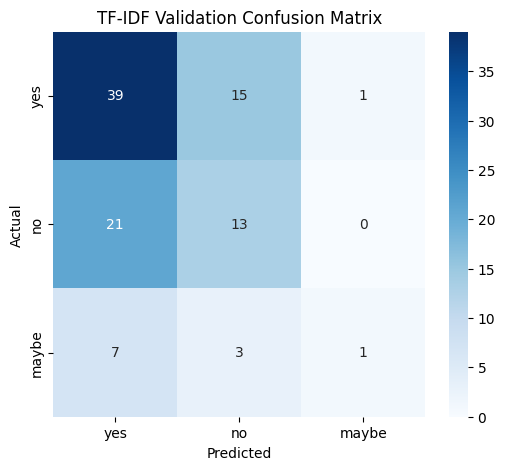


--- TF-IDF Test ---
Accuracy:    0.5060
Macro F1:    0.3581
Weighted F1: 0.4711

Classification Report:
              precision    recall  f1-score   support

       maybe     0.3077    0.0727    0.1176        55
          no     0.3840    0.2840    0.3265       169
         yes     0.5552    0.7283    0.6301       276

    accuracy                         0.5060       500
   macro avg     0.4156    0.3617    0.3581       500
weighted avg     0.4701    0.5060    0.4711       500



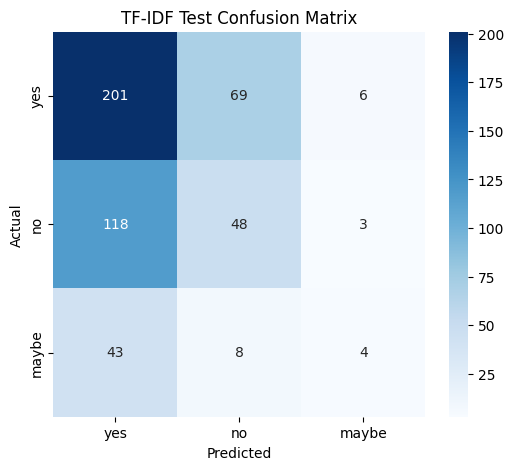

Saved: tfidf_test_predictions.csv


In [9]:
# -----------------------------
# TF-IDF baseline
# -----------------------------
X_train = train_df["text"].tolist()
X_val = val_df["text"].tolist()
X_test = test_df["text"].tolist()

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

tfidf_vectorizer = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED
)
tfidf_clf.fit(X_train_tfidf, y_train)

val_pred_tfidf = tfidf_clf.predict(X_val_tfidf)
test_pred_tfidf = tfidf_clf.predict(X_test_tfidf)

val_pred_tfidf_labels = [id2label[i] for i in val_pred_tfidf]
test_pred_tfidf_labels = [id2label[i] for i in test_pred_tfidf]

tfidf_val_metrics = evaluate_predictions(y_val, val_pred_tfidf, split_name="TF-IDF Validation")
tfidf_test_metrics = evaluate_predictions(y_test, test_pred_tfidf, split_name="TF-IDF Test")

tfidf_test_out = save_prediction_file(test_df, test_pred_tfidf_labels, "tfidf", "tfidf_test_predictions.csv")


## Model 2: TF-IDF + N-grams + Logistic Regression


--- TF-IDF + N-grams Validation ---
Accuracy:    0.5400
Macro F1:    0.3962
Weighted F1: 0.5047

Classification Report:
              precision    recall  f1-score   support

       maybe     1.0000    0.0909    0.1667        11
          no     0.4074    0.3235    0.3607        34
         yes     0.5833    0.7636    0.6614        55

    accuracy                         0.5400       100
   macro avg     0.6636    0.3927    0.3962       100
weighted avg     0.5694    0.5400    0.5047       100



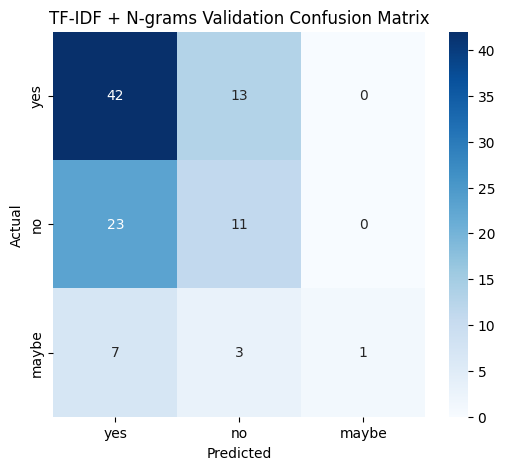


--- TF-IDF + N-grams Test ---
Accuracy:    0.5260
Macro F1:    0.3399
Weighted F1: 0.4774

Classification Report:
              precision    recall  f1-score   support

       maybe     0.2000    0.0182    0.0333        55
          no     0.4087    0.2781    0.3310       169
         yes     0.5658    0.7790    0.6555       276

    accuracy                         0.5260       500
   macro avg     0.3915    0.3584    0.3399       500
weighted avg     0.4725    0.5260    0.4774       500



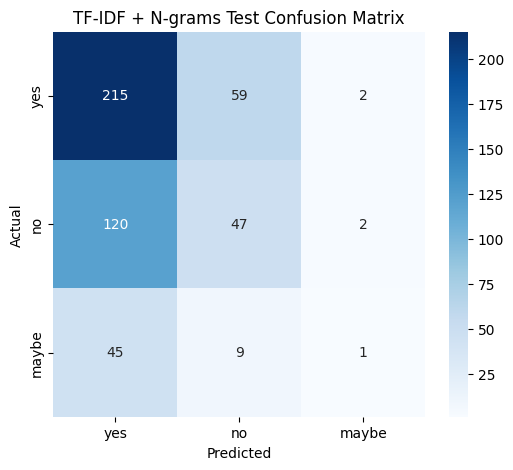

Saved: tfidf_ngram_test_predictions.csv


In [10]:
# -----------------------------
# TF-IDF + N-grams baseline
# -----------------------------
tfidf_ngram_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_ngram = tfidf_ngram_vectorizer.fit_transform(X_train)
X_val_ngram = tfidf_ngram_vectorizer.transform(X_val)
X_test_ngram = tfidf_ngram_vectorizer.transform(X_test)

tfidf_ngram_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED
)
tfidf_ngram_clf.fit(X_train_ngram, y_train)

val_pred_ngram = tfidf_ngram_clf.predict(X_val_ngram)
test_pred_ngram = tfidf_ngram_clf.predict(X_test_ngram)

val_pred_ngram_labels = [id2label[i] for i in val_pred_ngram]
test_pred_ngram_labels = [id2label[i] for i in test_pred_ngram]

tfidf_ngram_val_metrics = evaluate_predictions(y_val, val_pred_ngram, split_name="TF-IDF + N-grams Validation")
tfidf_ngram_test_metrics = evaluate_predictions(y_test, test_pred_ngram, split_name="TF-IDF + N-grams Test")

tfidf_ngram_test_out = save_prediction_file(test_df, test_pred_ngram_labels, "tfidf_ngram", "tfidf_ngram_test_predictions.csv")


## Model 3: Sentence-BERT + Logistic Regression

Recommended biomedical Sentence-BERT model:
- `pritamdeka/S-BioBert-snli-multinli-stsb`

If download is slow or unavailable, you can switch to:
- `sentence-transformers/all-MiniLM-L6-v2`


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Train embedding shape: (400, 768)
Val embedding shape: (100, 768)
Test embedding shape: (500, 768)

--- Sentence-BERT Validation ---
Accuracy:    0.4700
Macro F1:    0.3938
Weighted F1: 0.4721

Classification Report:
              precision    recall  f1-score   support

       maybe     0.2000    0.1818    0.1905        11
          no     0.4048    0.5000    0.4474        34
         yes     0.5833    0.5091    0.5437        55

    accuracy                         0.4700       100
   macro avg     0.3960    0.3970    0.3938       100
weighted avg     0.4805    0.4700    0.4721       100



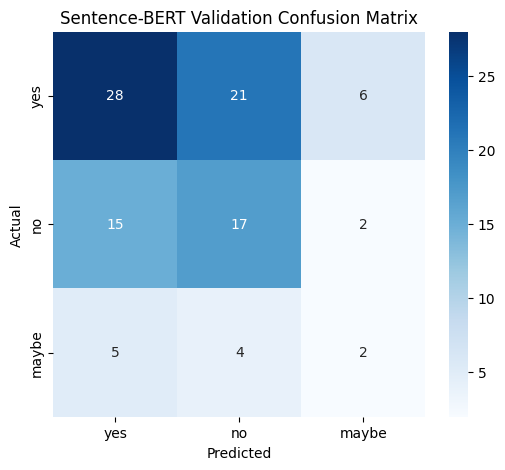


--- Sentence-BERT Test ---
Accuracy:    0.4460
Macro F1:    0.3843
Weighted F1: 0.4561

Classification Report:
              precision    recall  f1-score   support

       maybe     0.1786    0.2727    0.2158        55
          no     0.3908    0.4024    0.3965       169
         yes     0.5785    0.5072    0.5405       276

    accuracy                         0.4460       500
   macro avg     0.3826    0.3941    0.3843       500
weighted avg     0.4711    0.4460    0.4561       500



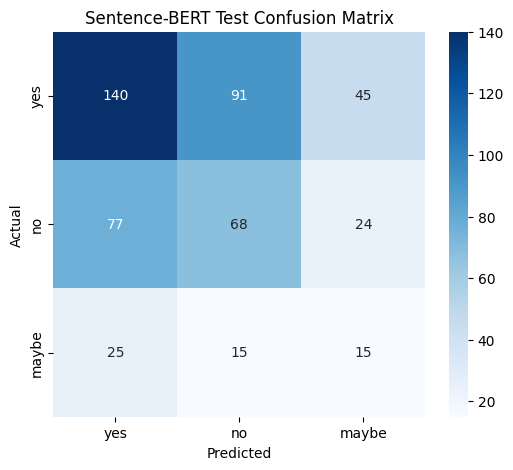

Saved: sbert_test_predictions.csv


In [11]:
# -----------------------------
# Sentence-BERT embeddings + classifier
# -----------------------------
SBERT_MODEL_NAME = "pritamdeka/S-BioBert-snli-multinli-stsb"
# SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

X_train_emb = sbert_model.encode(
    X_train,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X_val_emb = sbert_model.encode(
    X_val,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X_test_emb = sbert_model.encode(
    X_test,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Train embedding shape:", X_train_emb.shape)
print("Val embedding shape:", X_val_emb.shape)
print("Test embedding shape:", X_test_emb.shape)

sbert_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED
)
sbert_clf.fit(X_train_emb, y_train)

val_pred_sbert = sbert_clf.predict(X_val_emb)
test_pred_sbert = sbert_clf.predict(X_test_emb)

val_pred_sbert_labels = [id2label[i] for i in val_pred_sbert]
test_pred_sbert_labels = [id2label[i] for i in test_pred_sbert]

sbert_val_metrics = evaluate_predictions(y_val, val_pred_sbert, split_name="Sentence-BERT Validation")
sbert_test_metrics = evaluate_predictions(y_test, test_pred_sbert, split_name="Sentence-BERT Test")

np.save("X_train_sbert.npy", X_train_emb)
np.save("X_val_sbert.npy", X_val_emb)
np.save("X_test_sbert.npy", X_test_emb)

sbert_test_out = save_prediction_file(test_df, test_pred_sbert_labels, "sbert", "sbert_test_predictions.csv")


> Updated notebook note: the final BioBERT section now uses **question-context pair tokenization**, **class-weighted loss**, and **focused maybe-label diagnostics** so you can see whether the model still collapses to class `0` (`yes`).

## Model 4: BioBERT fine-tuning

This final BioBERT section is updated to reduce the common failure mode where the model predicts **class 0 (`yes`)** for many **`maybe`** rows.

Updates included:
- tokenize **question** and **context** as a pair instead of one merged string
- use **class-weighted cross-entropy** during training
- use a **version-safe** Trainer/TrainingArguments setup
- print a focused analysis for rows whose true label is **`maybe`**


In [12]:

# -----------------------------
# Prepare Hugging Face datasets for BioBERT
# -----------------------------
train_hf = Dataset.from_pandas(train_df[["question", "context", "label"]].reset_index(drop=True))
val_hf = Dataset.from_pandas(val_df[["question", "context", "label"]].reset_index(drop=True))
test_hf = Dataset.from_pandas(test_df[["question", "context", "label"]].reset_index(drop=True))

BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"
MAX_LENGTH = 512

biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_NAME)

def tokenize_function(batch):
    return biobert_tokenizer(
        batch["question"],
        batch["context"],
        truncation="only_second",   # keep the question, truncate the context first
        max_length=MAX_LENGTH,
        padding=False
    )

train_hf_tok = train_hf.map(tokenize_function, batched=True)
val_hf_tok = val_hf.map(tokenize_function, batched=True)
test_hf_tok = test_hf.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=biobert_tokenizer)

# Class weights to reduce the bias toward the majority class
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["label"].unique())),
    y=train_df["label"].values
).astype(np.float32)

class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print("Train label counts:")
print(train_df["label_text"].value_counts())
print("\nClass weights by label id:")
for idx, weight in enumerate(class_weights_np):
    print(f"{idx} ({id2label[idx]}): {weight:.4f}")


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train label counts:
label_text
yes      221
no       135
maybe     44
Name: count, dtype: int64

Class weights by label id:
0 (yes): 0.6033
1 (no): 0.9877
2 (maybe): 3.0303


In [13]:

# -----------------------------
# BioBERT model + metrics
# -----------------------------
biobert_model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        if return_outputs:
            return loss, outputs
        return loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

In [14]:

# -----------------------------
# BioBERT training
# -----------------------------
NUM_EPOCHS = 4
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
LEARNING_RATE = 1.5e-5

training_kwargs = {
    "output_dir": "./biobert_pubmedqa_outputs",
    "save_strategy": "epoch",
    "logging_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "macro_f1",
    "greater_is_better": True,
    "num_train_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,
    "weight_decay": 0.01,
    "save_total_limit": 2,
    "report_to": "none",
    "fp16": torch.cuda.is_available(),
    "seed": SEED,
    "warmup_ratio": 0.1,
}

ta_params = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in ta_params:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = {
    "model": biobert_model,
    "args": training_args,
    "train_dataset": train_hf_tok,
    "eval_dataset": val_hf_tok,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
}

trainer_params = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = biobert_tokenizer
else:
    trainer_kwargs["tokenizer"] = biobert_tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

trainer.train()


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.123726,1.078954,0.540000,0.310204,0.460408
2,1.039881,1.075499,0.470000,0.416667,0.472500
3,0.909085,1.064816,0.440000,0.352935,0.424577
4,0.798609,1.062202,0.450000,0.351185,0.445430


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=200, training_loss=0.9678252029418946, metrics={'train_runtime': 93.3041, 'train_samples_per_second': 17.148, 'train_steps_per_second': 2.144, 'total_flos': 389510636916240.0, 'train_loss': 0.9678252029418946, 'epoch': 4.0})


Validation predicted class counts:
0    38
1    50
2    12
Name: count, dtype: int64

Test predicted class counts:
0    192
1    258
2     50
Name: count, dtype: int64

Validation predicted label counts:
no       50
yes      38
maybe    12
Name: count, dtype: int64

Test predicted label counts:
no       258
yes      192
maybe     50
Name: count, dtype: int64

True test label counts:
label_text
yes      276
no       169
maybe     55
Name: count, dtype: int64

--- BioBERT Validation ---
Accuracy:    0.4800
Macro F1:    0.4257
Weighted F1: 0.4826

Classification Report:
              precision    recall  f1-score   support

       maybe     0.2500    0.2727    0.2609        11
          no     0.4200    0.6176    0.5000        34
         yes     0.6316    0.4364    0.5161        55

    accuracy                         0.4800       100
   macro avg     0.4339    0.4422    0.4257       100
weighted avg     0.5177    0.4800    0.4826       100



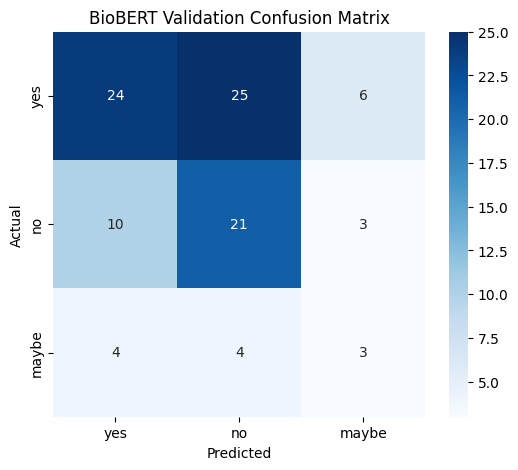


--- BioBERT Test ---
Accuracy:    0.4520
Macro F1:    0.3753
Weighted F1: 0.4519

Classification Report:
              precision    recall  f1-score   support

       maybe     0.1600    0.1455    0.1524        55
          no     0.3953    0.6036    0.4778       169
         yes     0.6042    0.4203    0.4957       276

    accuracy                         0.4520       500
   macro avg     0.3865    0.3898    0.3753       500
weighted avg     0.4847    0.4520    0.4519       500



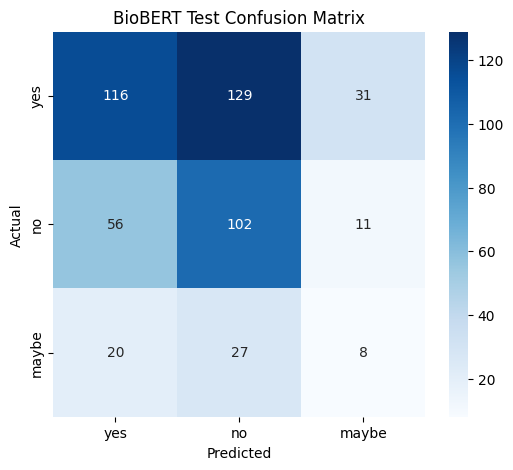


Saved: biobert_test_predictions.csv

Sample BioBERT test output:


,pmid,question,true_label,predicted_label,prob_yes,prob_no,prob_maybe,correct
0,21645374,Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?,yes,yes,0.361721,0.287002,0.351277,1
1,16418930,Landolt C and snellen e acuity: differences in strabismus amblyopia?,no,maybe,0.371080,0.237172,0.391748,0
2,9488747,"Syncope during bathing in infants, a pediatric form of water-induced urticaria?",yes,yes,0.378039,0.299711,0.322250,1
3,17208539,Are the long-term results of the transanal pull-through equal to those of the transabdominal pull-through?,no,yes,0.361488,0.349128,0.289384,0
4,26037986,30-Day and 1-year mortality in emergency general surgery laparotomies: an area of concern and need for improvement?,maybe,yes,0.357298,0.301141,0.341561,0
5,26852225,Is adjustment for reporting heterogeneity necessary in sleep disorders?,no,yes,0.356664,0.318232,0.325104,0
6,18239988,Differentiation of nonalcoholic from alcoholic steatohepatitis: are routine laboratory markers useful?,yes,no,0.363972,0.398478,0.237550,0
7,26578404,Patient-Controlled Therapy of Breathlessness in Palliative Care: A New Therapeutic Concept for Opioid Administration?,yes,yes,0.364615,0.305057,0.330328,1
8,22694248,Is there a model to teach and practice retroperitoneoscopic nephrectomy?,yes,yes,0.399013,0.282477,0.318510,1
9,19394934,Israeli hospital preparedness for terrorism-related multiple casualty incidents: can the surge capacity and injury severity distribution be better predicted?,yes,yes,0.353467,0.326305,0.320228,1



How many TRUE maybe rows are predicted as each class?
predicted_label
no       27
yes      20
maybe     8
Name: count, dtype: int64

Average predicted probabilities on TRUE maybe rows:


,prob_yes,prob_no,prob_maybe
mean_probability,0.351908,0.337477,0.310615



Sample rows where TRUE label is maybe:


,pmid,question,true_label,predicted_label,prob_yes,prob_no,prob_maybe,correct
4,26037986,30-Day and 1-year mortality in emergency general surgery laparotomies: an area of concern and need for improvement?,maybe,yes,0.357298,0.301141,0.341561,0
14,17940352,Does HER2 immunoreactivity provide prognostic information in locally advanced urothelial carcinoma patients receiving adjuvant M-VEC chemotherapy?,maybe,yes,0.379014,0.352246,0.268740,0
20,14599616,Can a practicing surgeon detect early lymphedema reliably?,maybe,yes,0.377590,0.278400,0.344010,0
23,26606599,Do Surrogates of Injury Severity Influence the Occurrence of Heterotopic Ossification in Fractures of the Acetabulum?,maybe,no,0.359464,0.401796,0.238740,0
25,25277731,Sternal fracture in growing children : A rare and often overlooked fracture?,maybe,no,0.327437,0.385815,0.286747,0
35,18235194,Is a specialised training of phonological awareness indicated in every preschool child?,maybe,no,0.340827,0.396913,0.262260,0
39,20337202,Continuation of pregnancy after antenatal corticosteroid administration: opportunity for rescue?,maybe,no,0.311234,0.428063,0.260702,0
42,26708803,Treatment of contralateral hydrocele in neonatal testicular torsion: Is less more?,maybe,no,0.340248,0.369697,0.290055,0
43,11570976,Is it Crohn's disease?,maybe,maybe,0.248796,0.149253,0.601951,1
45,27044366,Detailed analysis of sputum and systemic inflammation in asthma phenotypes: are paucigranulocytic asthmatics really non-inflammatory?,maybe,yes,0.382354,0.288036,0.329610,0


In [15]:

# -----------------------------
# BioBERT validation + test predictions
# -----------------------------
val_output_biobert = trainer.predict(val_hf_tok)
test_output_biobert = trainer.predict(test_hf_tok)

val_logits = val_output_biobert.predictions
test_logits = test_output_biobert.predictions

val_pred_biobert = np.argmax(val_logits, axis=1)
test_pred_biobert = np.argmax(test_logits, axis=1)

val_probs = torch.softmax(torch.tensor(val_logits), dim=1).numpy()
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

print("\nValidation predicted class counts:")
print(pd.Series(val_pred_biobert).value_counts().sort_index())

print("\nTest predicted class counts:")
print(pd.Series(test_pred_biobert).value_counts().sort_index())

print("\nValidation predicted label counts:")
print(pd.Series([id2label[i] for i in val_pred_biobert]).value_counts())

print("\nTest predicted label counts:")
print(pd.Series([id2label[i] for i in test_pred_biobert]).value_counts())

print("\nTrue test label counts:")
print(test_df["label_text"].value_counts())

val_pred_biobert_labels = [id2label[i] for i in val_pred_biobert]
test_pred_biobert_labels = [id2label[i] for i in test_pred_biobert]

biobert_val_metrics = evaluate_predictions(
    y_val,
    val_pred_biobert,
    split_name="BioBERT Validation"
)

biobert_test_metrics = evaluate_predictions(
    y_test,
    test_pred_biobert,
    split_name="BioBERT Test"
)

biobert_test_out = test_df.copy().reset_index(drop=True)
biobert_test_out["true_label"] = biobert_test_out["label_text"]
biobert_test_out["predicted_id"] = test_pred_biobert
biobert_test_out["predicted_label"] = test_pred_biobert_labels
biobert_test_out["prob_yes"] = test_probs[:, 0]
biobert_test_out["prob_no"] = test_probs[:, 1]
biobert_test_out["prob_maybe"] = test_probs[:, 2]
biobert_test_out["correct"] = (biobert_test_out["true_label"] == biobert_test_out["predicted_label"]).astype(int)

biobert_test_out.to_csv("biobert_test_predictions.csv", index=False)
print("\nSaved: biobert_test_predictions.csv")

print("\nSample BioBERT test output:")
display(
    biobert_test_out[["pmid", "question", "true_label", "predicted_label", "prob_yes", "prob_no", "prob_maybe", "correct"]].head(20)
)

print("\nHow many TRUE maybe rows are predicted as each class?")
true_maybe_mask = (biobert_test_out["true_label"] == "maybe")
true_maybe_preds = biobert_test_out.loc[true_maybe_mask, "predicted_label"]
if len(true_maybe_preds) > 0:
    print(true_maybe_preds.value_counts(dropna=False))
else:
    print("No 'maybe' rows found in the test split.")

print("\nAverage predicted probabilities on TRUE maybe rows:")
if true_maybe_mask.sum() > 0:
    display(
        biobert_test_out.loc[true_maybe_mask, ["prob_yes", "prob_no", "prob_maybe"]].mean().to_frame("mean_probability").T
    )
else:
    print("No 'maybe' rows found in the test split.")

print("\nSample rows where TRUE label is maybe:")
if true_maybe_mask.sum() > 0:
    display(
        biobert_test_out.loc[
            true_maybe_mask,
            ["pmid", "question", "true_label", "predicted_label", "prob_yes", "prob_no", "prob_maybe", "correct"]
        ].head(20)
    )
else:
    print("No 'maybe' rows found in the test split.")


### Added debug note

This notebook now includes:
- stronger `normalize_label()` cleaning
- explicit checks proving whether true `"maybe"` labels map to `2`
- safer `TrainingArguments` and `Trainer` usage
- extra diagnostics showing what BioBERT predicts on rows whose true label is `"maybe"`


## Final comparison table

In [16]:
results_summary = pd.DataFrame([
    {
        "model": "TF-IDF",
        "val_accuracy": tfidf_val_metrics["accuracy"],
        "val_macro_f1": tfidf_val_metrics["macro_f1"],
        "val_weighted_f1": tfidf_val_metrics["weighted_f1"],
        "test_accuracy": tfidf_test_metrics["accuracy"],
        "test_macro_f1": tfidf_test_metrics["macro_f1"],
        "test_weighted_f1": tfidf_test_metrics["weighted_f1"],
    },
    {
        "model": "TF-IDF + N-grams",
        "val_accuracy": tfidf_ngram_val_metrics["accuracy"],
        "val_macro_f1": tfidf_ngram_val_metrics["macro_f1"],
        "val_weighted_f1": tfidf_ngram_val_metrics["weighted_f1"],
        "test_accuracy": tfidf_ngram_test_metrics["accuracy"],
        "test_macro_f1": tfidf_ngram_test_metrics["macro_f1"],
        "test_weighted_f1": tfidf_ngram_test_metrics["weighted_f1"],
    },
    {
        "model": "Sentence-BERT + LR",
        "val_accuracy": sbert_val_metrics["accuracy"],
        "val_macro_f1": sbert_val_metrics["macro_f1"],
        "val_weighted_f1": sbert_val_metrics["weighted_f1"],
        "test_accuracy": sbert_test_metrics["accuracy"],
        "test_macro_f1": sbert_test_metrics["macro_f1"],
        "test_weighted_f1": sbert_test_metrics["weighted_f1"],
    },
    {
        "model": "BioBERT",
        "val_accuracy": biobert_val_metrics["accuracy"],
        "val_macro_f1": biobert_val_metrics["macro_f1"],
        "val_weighted_f1": biobert_val_metrics["weighted_f1"],
        "test_accuracy": biobert_test_metrics["accuracy"],
        "test_macro_f1": biobert_test_metrics["macro_f1"],
        "test_weighted_f1": biobert_test_metrics["weighted_f1"],
    }
])

results_summary = results_summary.sort_values(by=["test_macro_f1", "test_accuracy"], ascending=False).reset_index(drop=True)
results_summary


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Sentence-BERT + LR,0.47,0.393845,0.472087,0.446,0.384290,0.456137
1,BioBERT,0.48,0.425666,0.482567,0.452,0.375286,0.451883
2,TF-IDF,0.53,0.397730,0.504562,0.506,0.358091,0.471120
3,TF-IDF + N-grams,0.54,0.396247,0.504736,0.526,0.339936,0.477369


## Optional: answer-quality prediction task

This creates a binary target:
- `1` = model predicted correctly
- `0` = model predicted incorrectly

Below is an example using the **best model's prediction file** later.


In [17]:
# Example using BioBERT outputs for Task 3
quality_df = biobert_test_out.copy()

quality_df["question_len"] = quality_df["question"].fillna("").apply(lambda x: len(str(x).split()))
quality_df["context_len"] = quality_df["context"].fillna("").apply(lambda x: len(str(x).split()))
quality_df["quality"] = quality_df["correct"].astype(int)

quality_df[["pmid", "question_len", "context_len", "true_label", "predicted_label", "quality"]].head()


,pmid,question_len,context_len,true_label,predicted_label,quality
0,21645374,14,251,yes,yes,1
1,16418930,10,245,no,maybe,0
2,9488747,11,173,yes,yes,1
3,17208539,15,223,no,yes,0
4,26037986,17,142,maybe,yes,0


## Files produced by this notebook

- `tfidf_test_predictions.csv`
- `tfidf_ngram_test_predictions.csv`
- `sbert_test_predictions.csv`
- `biobert_test_predictions.csv`
- `X_train_sbert.npy`, `X_val_sbert.npy`, `X_test_sbert.npy`

These are useful for your report, error analysis, and Task 3.
